# Lab 7.05 - Time series analysis

In [67]:
# Package imports
# Importing the necessary packages
import numpy as np                                  # Scientific computing
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

### Exercise 5 - Alcoholic beverages sales

The file US Retail.csv contains monthly retail sales of beer, wine, and liquor at U.S. liquor stores.

- Is seasonality present in these data?
- Create a time series chart of the data. Based on what you see, which of the exponential smoothing models do you think should be used for forecasting? Why?
- Split the dataset in a train (1992-01-01 up to and including 2008-12-01) and test set (2009-01-01 up to and including 2009-12-01)  
- Create and train the model. 
- Predict the values for 2009.
- Create a plot with the train data, the fitted values, the test data and the predicted values.
- Calculate MAE

In [68]:
data = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/US%20Retail.csv', delimiter = ";", parse_dates=['Month']).set_index(['Month'])
data.head()

,Total Sales
Month,
1992-01-01,1519
1992-02-01,1551
1992-03-01,1606
1992-04-01,1686
1992-05-01,1834


There is clear seasonality visible within the dataset. It looks like december is a peak month for alcohol sales. Since there is clear seasonality the Holt-Winters method will be the most fitting.


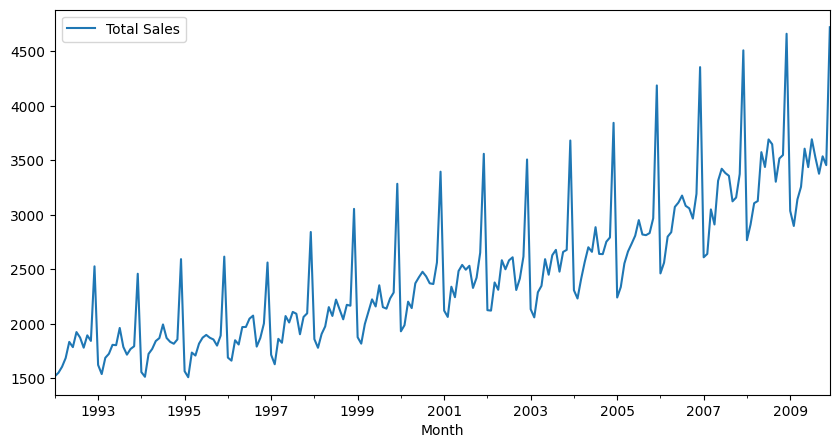

In [69]:
# Is seasonality present in these data?
# Create a time series chart of the data. Based on what you see, which of the exponential smoothing models do you think should be used for forecasting? Why?

data.plot(y='Total Sales', figsize=(10,5))
print('There is clear seasonality visible within the dataset. It looks like december is a peak month for alcohol sales. Since there is clear seasonality the Holt-Winters method will be the most fitting.')

In [70]:
# Split the dataset in a train (1992-01-01 up to and including 2008-12-01) and test set (2009-01-01 up to and including 2009-12-01)  
train = data[:'2008-12-01']
test = data['2009-01-01':]

In [71]:
#Create and train the model. 
from statsmodels.tsa.holtwinters import ExponentialSmoothing
data_tes = ExponentialSmoothing(train, seasonal='multiplicative', trend='add', seasonal_periods=12, freq='MS').fit()

In [72]:
# Predict the values for 2009.
tes_2009 = data_tes.forecast(12)
tes_2009.head(12)

2009-01-01    2969.924379
2009-02-01    2966.265393
2009-03-01    3280.304947
2009-04-01    3300.556792
2009-05-01    3607.350658
2009-06-01    3588.301025
2009-07-01    3747.378482
2009-08-01    3654.567365
2009-09-01    3459.993740
2009-10-01    3565.743201
2009-11-01    3713.210999
2009-12-01    5053.887944
Freq: MS, dtype: float64

<Axes: xlabel='Month'>

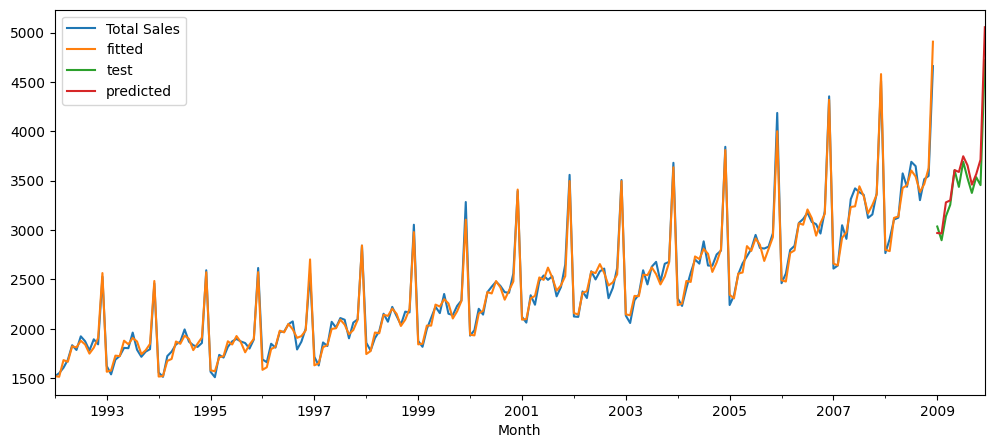

In [73]:
# Create a plot with the train data, the fitted values, the test data and the predicted values.
test['predicted'] = tes_2009

train.plot(y='Total Sales', figsize=(12,5))
data_tes.fittedvalues.plot(legend=True, label='fitted')
test['Total Sales'].plot(legend=True, label='test')
tes_2009.plot(legend=True, label='predicted')


In [77]:
# Calculate MAE
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_true=test['Total Sales'].values, y_pred=tes_2009.values)

print(mae)

113.71968064407433


## Source
Business Analytics Data Analysis & Decision Making 